## Import Libraries and Load Data

In [1]:
# Load core libraries and read the Hotazel Steam dataset into a dataframe

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

pd.options.display.float_format = '{:.2f}'.format

HS_data = pd.read_csv('AICPA_regressionAnalysisData.csv')

display(HS_data)


,type,date,revenue,production,coolDD,heatDD
0,dt4training,2011-01-31,23304096,659640,0,1021
1,dt4training,2011-02-28,24552000,686144,0,794
2,dt4training,2011-03-31,14804728,416464,0,714
3,dt4training,2011-04-30,11265320,324456,1,354
4,dt4training,2011-05-31,5945904,151104,72,114
5,dt4training,2011-06-30,10379712,479264,239,4
6,dt4training,2011-07-31,13617528,708472,486,0
7,dt4training,2011-08-31,14092512,687728,346,0
8,dt4training,2011-09-30,12085472,567424,195,19
9,dt4training,2011-10-31,11957032,392328,24,223


## Adjust Date Column

In [2]:
# Convert the date column to datetime format so that month values can be extracted to define the dummy variable

HS_data['date'] = pd.to_datetime(HS_data['date'])

display(HS_data)


,type,date,revenue,production,coolDD,heatDD
0,dt4training,2011-01-31,23304096,659640,0,1021
1,dt4training,2011-02-28,24552000,686144,0,794
2,dt4training,2011-03-31,14804728,416464,0,714
3,dt4training,2011-04-30,11265320,324456,1,354
4,dt4training,2011-05-31,5945904,151104,72,114
5,dt4training,2011-06-30,10379712,479264,239,4
6,dt4training,2011-07-31,13617528,708472,486,0
7,dt4training,2011-08-31,14092512,687728,346,0
8,dt4training,2011-09-30,12085472,567424,195,19
9,dt4training,2011-10-31,11957032,392328,24,223


## Create Winter Dummy Variable

In [3]:
# Create a dummy variable that equals 1 for December, January and February (winter months) and 0 for all other months
# This captures the seasonal shift in heating demand

# Winter months: December, January, February
HS_data['winter_DV'] = np.where(HS_data['date'].dt.month.isin([12,1,2]),1,0)

display(HS_data)


,type,date,revenue,production,coolDD,heatDD,winter_DV
0,dt4training,2011-01-31,23304096,659640,0,1021,1
1,dt4training,2011-02-28,24552000,686144,0,794,1
2,dt4training,2011-03-31,14804728,416464,0,714,0
3,dt4training,2011-04-30,11265320,324456,1,354,0
4,dt4training,2011-05-31,5945904,151104,72,114,0
5,dt4training,2011-06-30,10379712,479264,239,4,0
6,dt4training,2011-07-31,13617528,708472,486,0,0
7,dt4training,2011-08-31,14092512,687728,346,0,0
8,dt4training,2011-09-30,12085472,567424,195,19,0
9,dt4training,2011-10-31,11957032,392328,24,223,0


## Create Interaction Term

In [4]:
# Multiply production by the winter dummy to create an interaction term

HS_data['winter_interaction'] = HS_data['production'] * HS_data['winter_DV']

display(HS_data)


,type,date,revenue,production,coolDD,heatDD,winter_DV,winter_interaction
0,dt4training,2011-01-31,23304096,659640,0,1021,1,659640
1,dt4training,2011-02-28,24552000,686144,0,794,1,686144
2,dt4training,2011-03-31,14804728,416464,0,714,0,0
3,dt4training,2011-04-30,11265320,324456,1,354,0,0
4,dt4training,2011-05-31,5945904,151104,72,114,0,0
5,dt4training,2011-06-30,10379712,479264,239,4,0,0
6,dt4training,2011-07-31,13617528,708472,486,0,0,0
7,dt4training,2011-08-31,14092512,687728,346,0,0,0
8,dt4training,2011-09-30,12085472,567424,195,19,0,0
9,dt4training,2011-10-31,11957032,392328,24,223,0,0


## Split into Training and Testing Sets

In [5]:
# Separate data into training (2011 to 2013) and testing (2014) sets
# The dummy and interaction term columns are now present in both

dt4training = HS_data.loc[HS_data['type']=='dt4training']
dt4testing = HS_data.loc[HS_data['type']=='dt4testing']

display(dt4testing)


,type,date,revenue,production,coolDD,heatDD,winter_DV,winter_interaction
36,dt4testing,2014-01-31,19228840,606400,0,1123,1,606400
37,dt4testing,2014-02-28,26792280,714128,0,938,1,714128
38,dt4testing,2014-03-31,19935840,805600,0,866,0,0
39,dt4testing,2014-04-30,13468000,375856,0,412,0,0
40,dt4testing,2014-05-31,7344128,279296,49,88,0,0
41,dt4testing,2014-06-30,11196216,517600,230,0,0,0
42,dt4testing,2014-07-31,13929472,749472,380,0,0,0
43,dt4testing,2014-08-31,12352176,663432,322,0,0,0
44,dt4testing,2014-09-30,12628944,701656,178,14,0,0
45,dt4testing,2014-10-31,9361000,411728,24,166,0,0


## Build Model: Production, Winter Dummy and Interaction Term

In [6]:
# Define revenue as the dependent variable with production, the winter dummy and the interaction term as independent variables
# Fit an OLS regression on the training set

y = dt4training.loc[:,'revenue']
x = dt4training.loc[:,['production', 'winter_DV','winter_interaction']]
x = sm.add_constant(x)

model1 = sm.OLS(y,x).fit()

model1.params


,0
const,5629257.08
production,13.51
winter_DV,-201742.73
winter_interaction,14.16


## Model Equations

Non-winter months (winter_DV = 0):
revenue = 5,629,257.08 + 13.51 * production

Winter months (winter_DV = 1):
revenue = 5,427,515.08 + 27.67 * production

## Visualize Regression Lines by Season

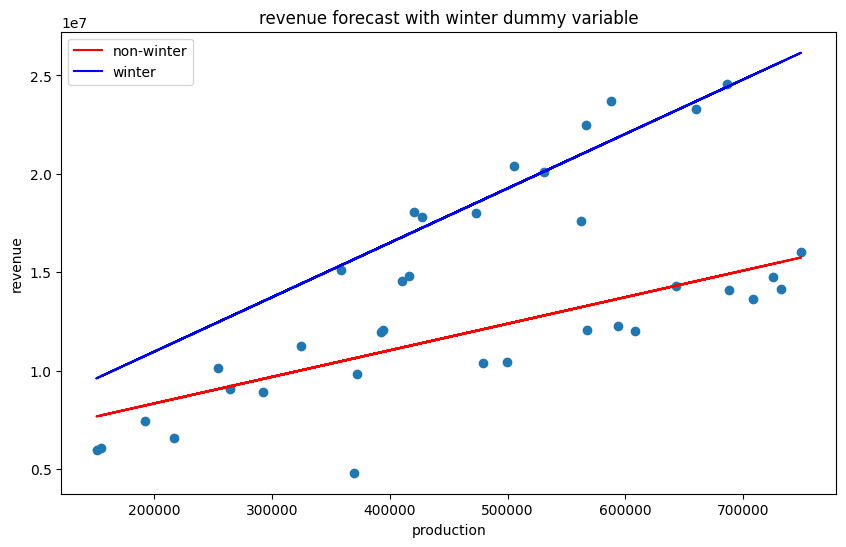

In [7]:
# Scatter plot actual training data points then overlay two regression lines showing how the winter dummy
# shifts the intercept and the interaction term changes the slope for winter months versus all others

plt.figure(figsize=(10,6))

plt.title('revenue forecast with winter dummy variable')
plt.xlabel('production')
plt.ylabel('revenue')

plt.scatter(dt4training['production'],dt4training['revenue'])

intercept, production_coefficient, winter_DV_intercept, winter_coefficient = model1.params

non_winter_line = intercept + production_coefficient * dt4training['production']
winter_line = (intercept + winter_DV_intercept) + (production_coefficient + winter_coefficient) * dt4training['production']

plt.plot(dt4training['production'], non_winter_line, color='red', label='non-winter')
plt.plot(dt4training['production'], winter_line, color='blue', label='winter')
plt.legend()


## Forecast on Testing Data

In [8]:
# Prepare the testing set independent variables including the winter dummy and interaction term then generate predicted revenues
# Calculate percentage error for each month

x_test = dt4testing.loc[:,['production','winter_DV','winter_interaction']]
x_test = sm.add_constant(x_test)

model1_assessment = dt4testing.copy()

model1_assessment['model1_predicted_revenue'] = model1.predict(x_test)

model1_assessment['pct_error'] = abs(
    (model1_assessment['revenue'] - model1_assessment['model1_predicted_revenue'])
    / model1_assessment['revenue']
)

display(model1_assessment)


,type,date,revenue,production,coolDD,heatDD,winter_DV,winter_interaction,model1_predicted_revenue,pct_error
36,dt4testing,2014-01-31,19228840,606400,0,1123,1,606400,22205317.42,0.15
37,dt4testing,2014-02-28,26792280,714128,0,938,1,714128,25185922.91,0.06
38,dt4testing,2014-03-31,19935840,805600,0,866,0,0,16509348.78,0.17
39,dt4testing,2014-04-30,13468000,375856,0,412,0,0,10705408.70,0.21
40,dt4testing,2014-05-31,7344128,279296,49,88,0,0,9401310.32,0.28
41,dt4testing,2014-06-30,11196216,517600,230,0,0,0,12619743.01,0.13
42,dt4testing,2014-07-31,13929472,749472,380,0,0,0,15751307.84,0.13
43,dt4testing,2014-08-31,12352176,663432,322,0,0,0,14589288.11,0.18
44,dt4testing,2014-09-30,12628944,701656,178,14,0,0,15105525.23,0.20
45,dt4testing,2014-10-31,9361000,411728,24,166,0,0,11189880.71,0.20


## MAPE Score

In [9]:
# Average the percentage errors across all 2014 testing months to produce the MAPE score for this dummy variable model

model1_assessment['pct_error'].mean()


np.float64(0.15896219012848184)

## Visualize Actual vs Predicted Revenue Over Time

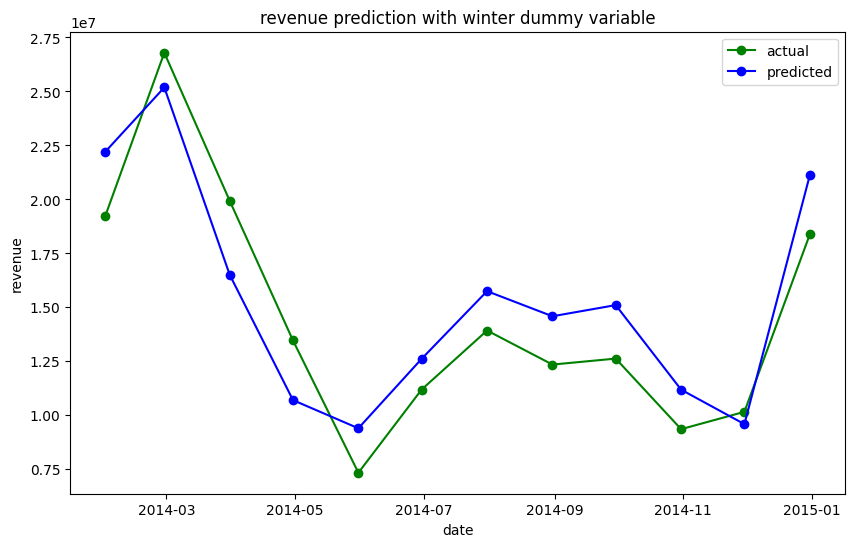

In [10]:
# Plot actual versus predicted revenue across the 2014 testing period as a time series

plt.figure(figsize=(10,6))

plt.title('revenue prediction with winter dummy variable')
plt.xlabel('date')
plt.ylabel('revenue')

plt.plot(model1_assessment['date'], model1_assessment['revenue'], marker='o', color='green', label='actual')
plt.plot(model1_assessment['date'], model1_assessment['model1_predicted_revenue'], marker='o', color='blue', label='predicted')
plt.legend()
